# CESNET Clustering 4 Slices (mMTC / eMBB / URLLC / URLLC+eMBB MIX)




In [ ]:
#Imports
import os, glob, tarfile
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)


## 1) Localiser les archives et extraire
Ce bloc cherche automatiquement `ip_addresses_sample.tar.gz` et `times.tar.gz` dans `/content` et dans Google Drive (si monté).

In [ ]:
import os
import shutil
from google.colab import drive

if os.path.exists("/content/drive") and not os.path.ismount("/content/drive"):
    shutil.rmtree("/content/drive")

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/5_6G_slicing_project

data			    lightning_logs  weekends_and_holidays.csv
ip_addresses_sample.tar.gz  scaler.pkl
kmeans_3clusters.pkl	    times.tar.gz


In [ ]:
import os, glob, tarfile

os.makedirs("data/ip_sample", exist_ok=True)
os.makedirs("data/times", exist_ok=True)

ip_tar = "/content/drive/MyDrive/5_6G_slicing_project/ip_addresses_sample.tar.gz"
times_tar = "/content/drive/MyDrive/5_6G_slicing_project/times.tar.gz"

print("IP tar exists   :", os.path.exists(ip_tar))
print("TIMES tar exists:", os.path.exists(times_tar))

with tarfile.open(ip_tar) as tar:
    tar.extractall("data/ip_sample")

with tarfile.open(times_tar) as tar:
    tar.extractall("data/times")

ip_csv = glob.glob("data/ip_sample/**/*.csv", recursive=True)
t_csv = glob.glob("data/times/**/*.csv", recursive=True)

print("IP CSV:", len(ip_csv))
print("TIME CSV:", len(t_csv))
print(ip_csv[:5])
print(t_csv[:5])

IP tar exists   : True
TIMES tar exists: True


/tmp/ipykernel_182/3666953329.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("data/ip_sample")


IP CSV: 3001
TIME CSV: 3
['data/ip_sample/ip_addresses_sample/identifiers.csv', 'data/ip_sample/ip_addresses_sample/agg_10_minutes/259860.csv', 'data/ip_sample/ip_addresses_sample/agg_10_minutes/1811876.csv', 'data/ip_sample/ip_addresses_sample/agg_10_minutes/476311.csv', 'data/ip_sample/ip_addresses_sample/agg_10_minutes/178.csv']
['data/times/times/times_10_minutes.csv', 'data/times/times/times_1_hour.csv', 'data/times/times/times_1_day.csv']


/tmp/ipykernel_182/3666953329.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("data/times")


## 2) Construire df_points (agg_10_minutes)
On charge `times_10_minutes.csv` puis les fichiers `agg_10_minutes/*.csv` et on fusionne pour obtenir `timestamp`.

In [ ]:
import os, glob
import pandas as pd
import numpy as np

#Charger le mapping temps 10 minutes
time_path = "data/times/times/times_10_minutes.csv"
df_t = pd.read_csv(time_path)
if "time_id" in df_t.columns and "id_time" not in df_t.columns:
    df_t = df_t.rename(columns={"time_id": "id_time"})

agg_files = sorted(glob.glob("data/ip_sample/ip_addresses_sample/agg_10_minutes/*.csv"))
if len(agg_files) == 0:
    raise FileNotFoundError("Aucun fichier agg_10_minutes trouvé.")

DEBUG = False
DEBUG_N_FILES = 300
use_files = agg_files[:DEBUG_N_FILES] if DEBUG else agg_files

dfs = []
bad = 0

for f in use_files:
    try:
        d = pd.read_csv(f)

        # ip_id est dans le nom du fichier: ".../agg_10_minutes/1802574.csv"
        ip_id = os.path.splitext(os.path.basename(f))[0]
        d["ip_id"] = int(ip_id)

        dfs.append(d)
    except Exception as e:
        bad += 1

df_ip = pd.concat(dfs, ignore_index=True)

# Harmonisation id_time si besoin
if "time_id" in df_ip.columns and "id_time" not in df_ip.columns:
    df_ip = df_ip.rename(columns={"time_id": "id_time"})

if "id_time" in df_ip.columns and "id_time" in df_t.columns:
    df_points = df_ip.merge(df_t, on="id_time", how="left")
else:
    df_points = df_ip.copy()

print("df_points:", df_points.shape, "| bad files:", bad)
print("Has ip_id ?", "ip_id" in df_points.columns, "| unique ip_id:", df_points["ip_id"].nunique())
print("Has timestamp ?", "timestamp" in df_points.columns)
display(df_points.head())

df_points: (6863540, 15) | bad files: 0
Has ip_id ? True | unique ip_id: 1000
Has timestamp ? False


,id_time,n_flows,n_packets,n_bytes,n_dest_asn,n_dest_ports,n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl,ip_id,time
0,0,14,96,11462,12.0,13.0,12.0,1.00,1.00,0.51,0.54,3.84,177.36,100610,2023-10-09 02:03:49+02:00
1,1,14,53,6413,11.0,12.0,12.0,0.87,0.87,0.51,0.55,0.78,109.57,100610,2023-10-09 02:13:49+02:00
2,2,15,96,12698,11.0,12.0,12.0,0.91,0.94,0.44,0.46,1.85,80.80,100610,2023-10-09 02:23:49+02:00
3,3,9,59,7822,7.0,9.0,9.0,0.90,0.93,0.59,0.67,1.45,74.56,100610,2023-10-09 02:33:49+02:00
4,4,16,75,9862,9.0,14.0,13.0,0.99,0.99,0.63,0.73,0.97,128.31,100610,2023-10-09 02:43:49+02:00


## 3) Feature engineering + Clustering (k=4)
On construit des features cohérentes avec :
- **taille paquet** (`avg_pkt_size`)
- **intensité / volume** (`n_bytes`, `bytes_per_flow`)
- **interactivité/pattern** (`burst_cv` proxy)

Puis KMeans `k=4` + mapping cluster -> slice via scoring sur centroïdes (assignation 1-1).

In [ ]:
#Clustering pipeline

FEATURES_BASE = [
    "n_bytes",
    "n_packets",
    "n_flows",
    "tcp_udp_ratio_bytes",
    "dir_ratio_bytes",
]

# Vérifier que les colonnes existent, sinon proposer les colonnes disponibles
missing_base = [c for c in FEATURES_BASE if c not in df_points.columns]
if missing_base:
    print("Colonnes manquantes (FEATURES_BASE):", missing_base)
    print("Colonnes dispo (extrait):", list(df_points.columns)[:80])
    raise KeyError("Adapte FEATURES_BASE aux noms réels de tes colonnes CESNET puis relance.")

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1e-9


    df["avg_pkt_size"]   = df["n_bytes"] / (df["n_packets"] + eps)
    df["bytes_per_flow"] = df["n_bytes"] / (df["n_flows"] + eps)
    df["pkts_per_flow"]  = df["n_packets"] / (df["n_flows"] + eps)

    for col in ["n_bytes","n_packets","n_flows","avg_pkt_size","bytes_per_flow","pkts_per_flow"]:
        df[col] = np.log1p(df[col].astype(float))

    df["burst_cv"] = 0.0
    if "ip_id" in df.columns:
        g = df.groupby("ip_id")["n_bytes"]
        mean_per_ip = g.transform("mean")
        std_per_ip  = g.transform("std").fillna(0.0)

        df["burst_cv"] = std_per_ip / (mean_per_ip + 1e-9)
        df["burst_cv"] = np.clip(df["burst_cv"], 0, 10)

    return df

df_feat = add_engineered_features(df_points)

FEATURES = FEATURES_BASE + ["avg_pkt_size","bytes_per_flow","pkts_per_flow","burst_cv"]

# Clean
df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES).copy()
X = df_feat[FEATURES].astype(float).values

# Scale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled:", X_scaled.shape)

# KMeans
k = 4
kmeans = KMeans(n_clusters=k, random_state=SEED, n_init="auto")
df_feat["cluster"] = kmeans.fit_predict(X_scaled)

# Silhouette
m = min(20000, len(df_feat))
idx = np.random.choice(len(df_feat), size=m, replace=False)
sil = silhouette_score(X_scaled[idx], df_feat["cluster"].values[idx])
print("silhouette (approx):", round(float(sil), 4))
print(df_feat["cluster"].value_counts())

# Centroïdes
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=FEATURES)
centroids_df["cluster"] = np.arange(k)

# Scoring slice
def score_slices(row):

    nb = row["n_bytes"]
    ap = row["avg_pkt_size"]
    nf = row["n_flows"]
    bc = row["burst_cv"]

    score_embb = (2.0*nb + 1.5*ap - 1.0*bc - 0.3*nf)

    score_mmtc = (-2.0*nb - 1.0*ap - 0.5*nf - 0.2*bc)

    score_urllc = (-1.2*ap + 1.2*nf + 2.0*bc - 0.6*nb)

    score_mix = (1.5*nb + 1.2*ap + 0.8*nf + 2.0*bc)

    return pd.Series({
        "eMBB": score_embb,
        "mMTC": score_mmtc,
        "URLLC": score_urllc,
        "URLLC_eMBB_MIX": score_mix,
    })

scores = centroids_df.set_index("cluster").apply(score_slices, axis=1)

assigned = {}
used = set()
order = scores.max(axis=1).sort_values(ascending=False).index.tolist()
for cl in order:
    prefs = scores.loc[cl].sort_values(ascending=False)
    for s in prefs.index:
        if s not in used:
            assigned[cl] = s
            used.add(s)
            break

cluster_to_slice = assigned
print("cluster_to_slice:", cluster_to_slice)

df_feat["slice"] = df_feat["cluster"].map(cluster_to_slice)

print("\nCounts per slice:")
display(df_feat["slice"].value_counts())


X_scaled: (6863540, 9)
silhouette (approx): 0.2677
cluster
3    2843167
1    2442210
0    1173203
2     404960
Name: count, dtype: int64
cluster_to_slice: {2: 'eMBB', 1: 'URLLC_eMBB_MIX', 0: 'URLLC', 3: 'mMTC'}

Counts per slice:


,count
slice,
mMTC,2843167
URLLC_eMBB_MIX,2442210
URLLC,1173203
eMBB,404960


## 4) Diagnostics
Vérifie surtout que **MIX ≈ eMBB** en volume/taille paquets mais **plus interactif** (`n_flows` et/ou `burst_cv` plus élevés).

=== Centroïdes (moyennes) ===


,n_bytes,n_packets,n_flows,tcp_udp_ratio_bytes,dir_ratio_bytes,avg_pkt_size,bytes_per_flow,pkts_per_flow,burst_cv
cluster,,,,,,,,,
0,8.422,4.313,3.489,0.294,0.480,4.150,4.987,1.246,0.140
1,10.831,5.098,2.348,0.909,0.426,5.750,8.624,2.958,0.222
2,17.406,11.138,7.194,0.671,0.284,6.272,10.218,4.063,0.126
3,6.039,2.127,1.611,0.749,0.491,4.100,4.702,1.082,0.202


=== Centroïdes (percentiles) ===


,n_bytes,n_packets,n_flows,tcp_udp_ratio_bytes,dir_ratio_bytes,avg_pkt_size,bytes_per_flow,pkts_per_flow,burst_cv
cluster,,,,,,,,,
0,0.50,0.50,0.75,0.25,0.75,0.50,0.50,0.50,0.50
1,0.75,0.75,0.50,1.00,0.50,0.75,0.75,0.75,1.00
2,1.00,1.00,1.00,0.50,0.25,1.00,1.00,1.00,0.25
3,0.25,0.25,0.25,0.75,1.00,0.25,0.25,0.25,0.75


=== eMBB vs MIX (moyennes sur proxys clés) ===


,n_bytes,avg_pkt_size,n_flows,burst_cv
slice,,,,
URLLC,8.422,4.150,3.489,0.140
URLLC_eMBB_MIX,10.831,5.750,2.348,0.222
eMBB,17.406,6.272,7.194,0.126
mMTC,6.039,4.100,1.611,0.202


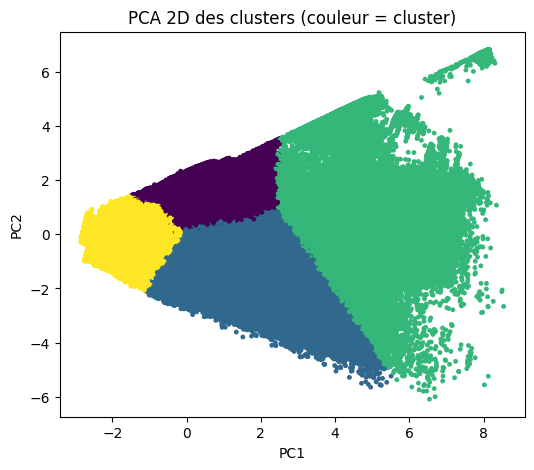

In [ ]:
#Diagnostics
print("=== Centroïdes (moyennes) ===")
display(df_feat.groupby("cluster")[FEATURES].mean().round(3))

print("=== Centroïdes (percentiles) ===")
centroids = df_feat.groupby("cluster")[FEATURES].mean()
display(centroids.rank(pct=True).round(3))

cols_check = [c for c in ["n_bytes","avg_pkt_size","n_flows","burst_cv"] if c in df_feat.columns]
print("=== eMBB vs MIX (moyennes sur proxys clés) ===")
display(df_feat.groupby("slice")[cols_check].mean().round(3))

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_feat["cluster"], s=6)
plt.title("PCA 2D des clusters (couleur = cluster)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 5) Export
Export CSV propre avec `cluster` + `slice`. Code robuste aux variations de noms (`ip_id`, `timestamp`, etc.).

In [ ]:
#Export
OUT_PATH = "cesnet_points_clustered_4slices.csv"

id_candidates = ["ip_id", "id_ip", "ip", "src_ip"]
time_candidates = ["timestamp", "time", "datetime", "date_time"]
id_time_candidates = ["id_time", "time_id"]

def first_existing(cands, df):
    for c in cands:
        if c in df.columns:
            return c
    return None

col_ip = first_existing(id_candidates, df_feat)
col_ts = first_existing(time_candidates, df_feat)
col_id_time = first_existing(id_time_candidates, df_feat)

if col_ts is None:
    try:
        df_t2 = pd.read_csv("data/times/times/times_10_minutes.csv")
        if "time_id" in df_t2.columns and "id_time" not in df_t2.columns:
            df_t2 = df_t2.rename(columns={"time_id": "id_time"})
        if "id_time" in df_feat.columns and "id_time" in df_t2.columns:
            df_feat = df_feat.merge(df_t2, on="id_time", how="left")
            col_ts = first_existing(time_candidates, df_feat)
    except Exception as e:
        print("timestamp non reconstruit:", e)

cols_out = []
for c in [col_ip, col_id_time, col_ts]:
    if c is not None:
        cols_out.append(c)

for c in FEATURES_BASE:
    if c in df_feat.columns:
        cols_out.append(c)

for c in ["avg_pkt_size","bytes_per_flow","pkts_per_flow","burst_cv"]:
    if c in df_feat.columns:
        cols_out.append(c)

cols_out += ["cluster","slice"]
cols_out = list(dict.fromkeys(cols_out))

missing = [c for c in cols_out if c not in df_feat.columns]
if missing:
    raise KeyError(f"Colonnes manquantes pour export: {missing}")

df_feat[cols_out].to_csv(OUT_PATH, index=False)
print("saved:", OUT_PATH, "| rows:", len(df_feat), "| cols:", len(cols_out))
print("Export columns:", cols_out)


saved: cesnet_points_clustered_4slices.csv | rows: 6863540 | cols: 14
Export columns: ['ip_id', 'id_time', 'time', 'n_bytes', 'n_packets', 'n_flows', 'tcp_udp_ratio_bytes', 'dir_ratio_bytes', 'avg_pkt_size', 'bytes_per_flow', 'pkts_per_flow', 'burst_cv', 'cluster', 'slice']


## 6) Sauvegarder le modèle

In [ ]:
# Sauvegarde
import joblib

SAVE_PATH = "/content/drive/MyDrive/5_6G_slicing_project/models/"

import os
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(kmeans, SAVE_PATH + "kmeans_4clusters.pkl")
joblib.dump(scaler, SAVE_PATH + "scaler_4clusters.pkl")
joblib.dump(cluster_to_slice, SAVE_PATH + "cluster_to_slice.pkl")

print("Modèles sauvegardés dans", SAVE_PATH)


Modèles sauvegardés dans /content/drive/MyDrive/5_6G_slicing_project/models/
